# Análise das Bases de Dados BraTS 2026 GoAT

Análise exploratória dos datasets de treinamento e validação BraTS-GoAT 2026 e das frações de teste externas de desafios anteriores.

In [1]:
from pathlib import Path
import random
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, **kw): return iterable

## Configuração dos Caminhos

In [2]:
DATASETS = {
    'BraTS_2026_GoAT_Training_Com_Labels': 'D:/brats_goat_experiments/data/raw_oficial_training_validation_set/MICCAI2024-BraTS-GoAT-TrainingData-With-GroundTruth',
    'BraTS_2026_GoAT_Training_Sem_Labels': 'D:/brats_goat_experiments/data/raw_oficial_training_validation_set/MICCAI2024-BraTS-GoAT-TrainingData-WithOut-GroundTruth',
    'BraTS_2026_GoAT_Validation':          'D:/brats_goat_experiments/data/raw_oficial_training_validation_set/MICCAI2024-BraTS-GoAT-ValidationData',
    'Fracao_Teste_Adult_Glioma':           'D:/brats_goat_experiments/data/raw_outside_test_set/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData',
    'Fracao_Teste_Meningioma':             'D:/brats_goat_experiments/data/raw_outside_test_set/BraTS-MEN-Train',
    'Fracao_Teste_Africa':                 'D:/brats_goat_experiments/data/raw_outside_test_set/BraTS-Africa',
    'Fracao_Teste_Pediatric':              'D:/brats_goat_experiments/data/raw_outside_test_set/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData',
    'Fracao_Teste_Metastases':             'CAMINHO_AQUI',  # não disponível ainda
}

MODALITIES     = ['t1n', 't1c', 't2w', 't2f', 'seg']
IMG_MODALITIES = ['t1n', 't1c', 't2w', 't2f']

## Funções de Análise

In [3]:
def find_patient_dirs(root_path):
    root = Path(root_path)
    return sorted([d for d in root.rglob('*')
                   if d.is_dir() and (list(d.glob('*.nii.gz')) or list(d.glob('*.nii')))])


def analyze_dataset(name, path_str):
    path = Path(path_str)
    if not path.exists():
        print(f'[AVISO] Caminho não encontrado: {path_str}')
        return None, []

    patient_dirs = find_patient_dirs(path)
    records, incomplete = [], []
    shapes_set = set()

    for pdir in patient_dirs:
        files = list(pdir.glob('*.nii.gz')) + list(pdir.glob('*.nii'))
        bases = [f.name.replace('.nii.gz', '').replace('.nii', '') for f in files]
        mod_present = {
            mod: any(b.endswith(f'-{mod}') or b.endswith(f'_{mod}') for b in bases)
            for mod in MODALITIES
        }
        missing_img = [m for m in IMG_MODALITIES if not mod_present[m]]
        is_complete = len(missing_img) == 0

        # Lê o shape do header do primeiro arquivo (rápido, sem carregar voxels)
        for f in files:
            try:
                shapes_set.add(tuple(nib.load(str(f)).shape))
                break
            except Exception:
                continue

        records.append({'paciente': pdir.name, **{m: int(mod_present[m]) for m in MODALITIES}, 'completo': is_complete})
        if not is_complete:
            missing_all = [m for m in MODALITIES if not mod_present[m]]
            incomplete.append({'dataset': name, 'paciente': pdir.name, 'modalidades_faltando': ', '.join(missing_all)})

    df = pd.DataFrame(records) if records else pd.DataFrame(columns=['paciente'] + MODALITIES + ['completo'])
    shapes_str = '; '.join(str(s) for s in sorted(shapes_set)) if shapes_set else ''

    summary = pd.DataFrame([{
        'dataset':         name,
        'total_pacientes': len(patient_dirs),
        **{m: int(df[m].sum()) if len(df) else 0 for m in MODALITIES},
        'completos':       int(df['completo'].sum())    if len(df) else 0,
        'incompletos':     int((~df['completo']).sum()) if len(df) else 0,
        'shapes':          shapes_str,
    }])
    return summary, incomplete

In [4]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# Colormap padrão do projeto: bg=preto, NCR=vermelho, Edema=verde, ET=azul
_CMAP_SEG = ListedColormap([(0,0,0,1),(1,0,0,1),(0,1,0,1),(0,0,1,1)])
_NORM_SEG  = BoundaryNorm([0,1,2,3,4], _CMAP_SEG.N)


def _mod_file(pdir, mod):
    files = [f for f in pdir.glob('*.nii.gz')
             if f.name.replace('.nii.gz', '').endswith(f'-{mod}')
             or f.name.replace('.nii.gz', '').endswith(f'_{mod}')]
    return files[0] if files else None


def _best_z(vol):
    margin = max(1, int(vol.shape[2] * 0.10))
    counts = np.sum(vol > 0, axis=(0, 1))
    counts[:margin]  = 0
    counts[-margin:] = 0
    return int(np.argmax(counts))


def plot_dataset_example(ds_name, path_str):
    path = Path(path_str)
    if not path.exists():
        return

    pdirs = find_patient_dirs(path)
    if not pdirs:
        return

    pdir = random.choice(pdirs)

    seg_file = _mod_file(pdir, 'seg')
    seg_vol  = nib.load(str(seg_file)).get_fdata() if seg_file else None

    ref_file = _mod_file(pdir, 't1c') or _mod_file(pdir, 't1n')
    ref_vol  = nib.load(str(ref_file)).get_fdata() if ref_file else None

    if seg_vol is not None:
        z = _best_z(seg_vol)
    elif ref_vol is not None:
        thr = np.percentile(ref_vol, 90)
        z   = _best_z((ref_vol > thr).astype(np.float32))
    else:
        return

    cols = [(mod, _mod_file(pdir, mod)) for mod in IMG_MODALITIES]
    cols = [(mod, f) for mod, f in cols if f is not None]
    if seg_file:
        cols.append(('seg', seg_file))

    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 4))
    axes = np.atleast_1d(axes)
    fig.suptitle(f'{ds_name}  |  {pdir.name}  |  z = {z}', fontsize=11)

    for ax, (mod, fpath) in zip(axes, cols):
        sl = np.rot90(nib.load(str(fpath)).get_fdata()[:, :, z])
        if mod == 'seg':
            ax.imshow(sl, cmap=_CMAP_SEG, norm=_NORM_SEG, interpolation='nearest')
        else:
            nz = sl[sl > 0]
            p2, p98 = (np.percentile(nz, [2, 98]) if nz.size else (0, 1))
            ax.imshow(sl, cmap='gray', vmin=p2, vmax=p98, interpolation='nearest')
        ax.set_title(mod, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

---
## BraTS 2026 — Training com Ground Truth

In [5]:
name = 'BraTS_2026_GoAT_Training_Com_Labels'
summary_com_labels, incomplete_com_labels = analyze_dataset(name, DATASETS[name])
if summary_com_labels is not None:
    display(summary_com_labels)

,dataset,total_pacientes,t1n,t1c,t2w,t2f,seg,completos,incompletos,shapes
0,BraTS_2026_GoAT_Training_Com_Labels,1351,1351,1351,1351,1351,1351,1351,0,"(240, 240, 155)"


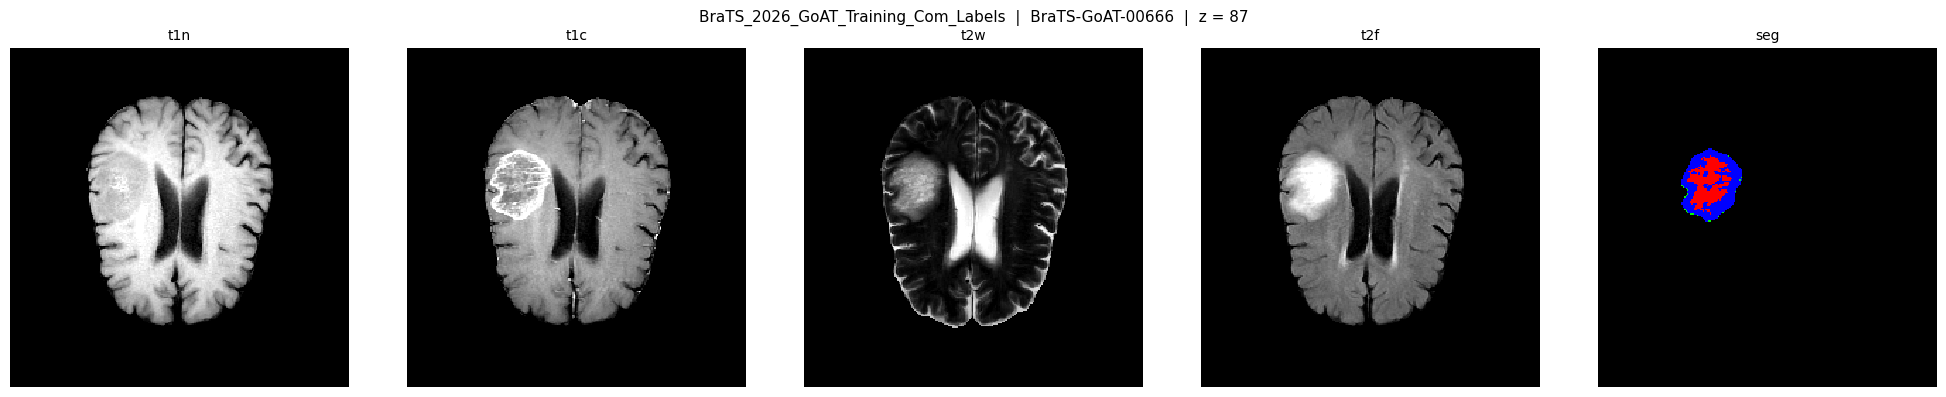

In [6]:
plot_dataset_example('BraTS_2026_GoAT_Training_Com_Labels', DATASETS['BraTS_2026_GoAT_Training_Com_Labels'])

## BraTS 2026 — Training sem Ground Truth

In [7]:
name = 'BraTS_2026_GoAT_Training_Sem_Labels'
summary_sem_labels, incomplete_sem_labels = analyze_dataset(name, DATASETS[name])
if summary_sem_labels is not None:
    display(summary_sem_labels)

,dataset,total_pacientes,t1n,t1c,t2w,t2f,seg,completos,incompletos,shapes
0,BraTS_2026_GoAT_Training_Sem_Labels,1138,1138,1138,1138,1138,0,1138,0,"(240, 240, 155)"


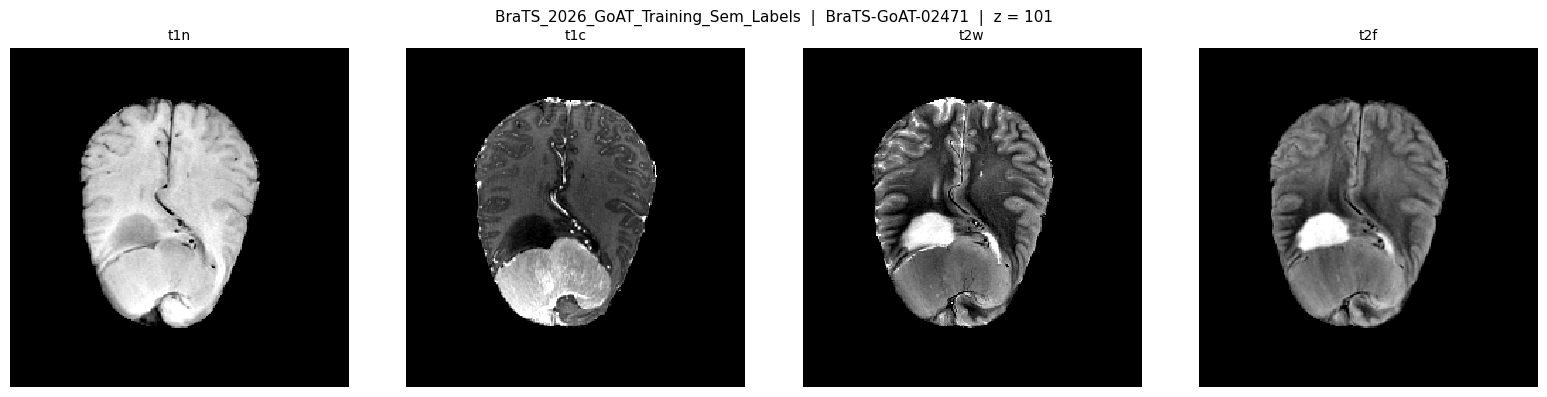

In [8]:
plot_dataset_example('BraTS_2026_GoAT_Training_Sem_Labels', DATASETS['BraTS_2026_GoAT_Training_Sem_Labels'])

## BraTS 2026 — Validation

In [9]:
name = 'BraTS_2026_GoAT_Validation'
summary_validation, incomplete_validation = analyze_dataset(name, DATASETS[name])
if summary_validation is not None:
    display(summary_validation)

,dataset,total_pacientes,t1n,t1c,t2w,t2f,seg,completos,incompletos,shapes
0,BraTS_2026_GoAT_Validation,451,451,451,451,451,0,451,0,"(240, 240, 155)"


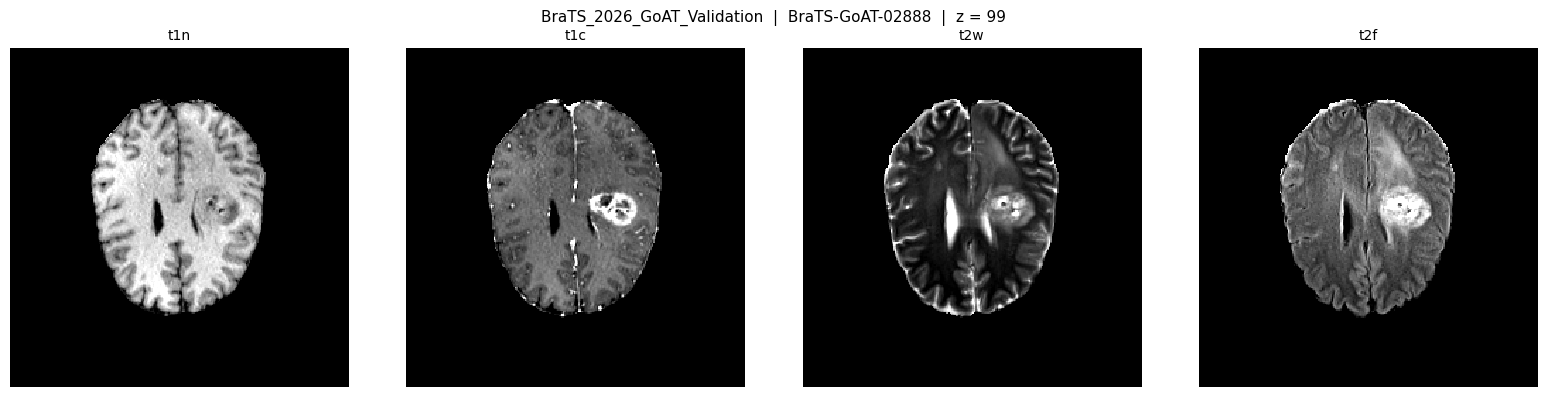

In [10]:
plot_dataset_example('BraTS_2026_GoAT_Validation', DATASETS['BraTS_2026_GoAT_Validation'])

---
## Fração de Teste — Adult Glioma

In [11]:
name = 'Fracao_Teste_Adult_Glioma'
summary_glioma, incomplete_glioma = analyze_dataset(name, DATASETS[name])
if summary_glioma is not None:
    display(summary_glioma)

,dataset,total_pacientes,t1n,t1c,t2w,t2f,seg,completos,incompletos,shapes
0,Fracao_Teste_Adult_Glioma,1251,1251,1251,1251,1251,1251,1251,0,"(240, 240, 155)"


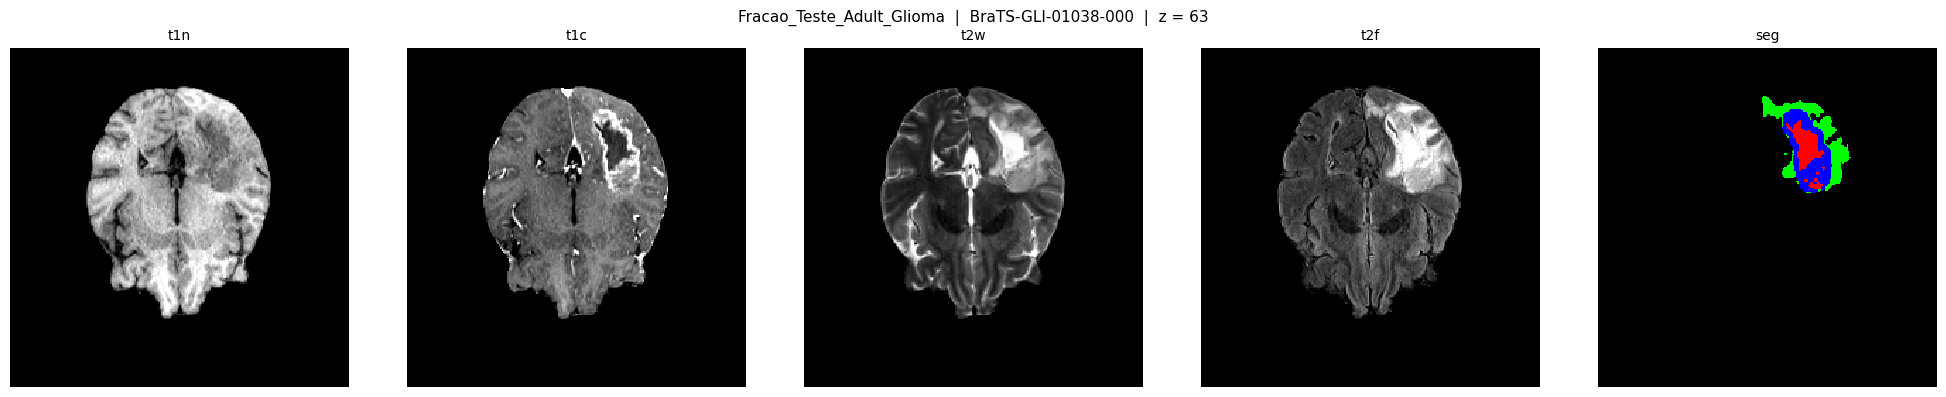

In [12]:
plot_dataset_example('Fracao_Teste_Adult_Glioma', DATASETS['Fracao_Teste_Adult_Glioma'])

## Fração de Teste — Meningioma

In [13]:
name = 'Fracao_Teste_Meningioma'
summary_men, incomplete_men = analyze_dataset(name, DATASETS[name])
if summary_men is not None:
    display(summary_men)

,dataset,total_pacientes,t1n,t1c,t2w,t2f,seg,completos,incompletos,shapes
0,Fracao_Teste_Meningioma,1000,1000,1000,1000,1000,1000,1000,0,"(240, 240, 155)"


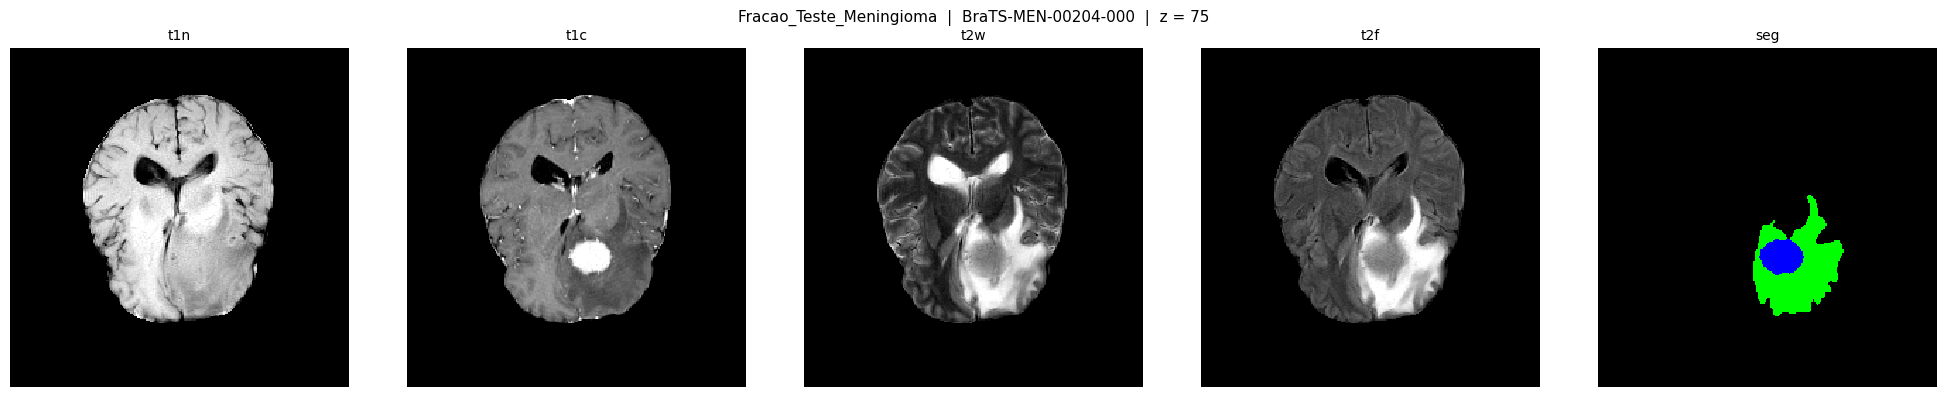

In [14]:
plot_dataset_example('Fracao_Teste_Meningioma', DATASETS['Fracao_Teste_Meningioma'])

## Fração de Teste — Africa

In [15]:
name = 'Fracao_Teste_Africa'
summary_africa, incomplete_africa = analyze_dataset(name, DATASETS[name])
if summary_africa is not None:
    display(summary_africa)

,dataset,total_pacientes,t1n,t1c,t2w,t2f,seg,completos,incompletos,shapes
0,Fracao_Teste_Africa,146,146,146,146,146,146,146,0,"(240, 240, 155)"


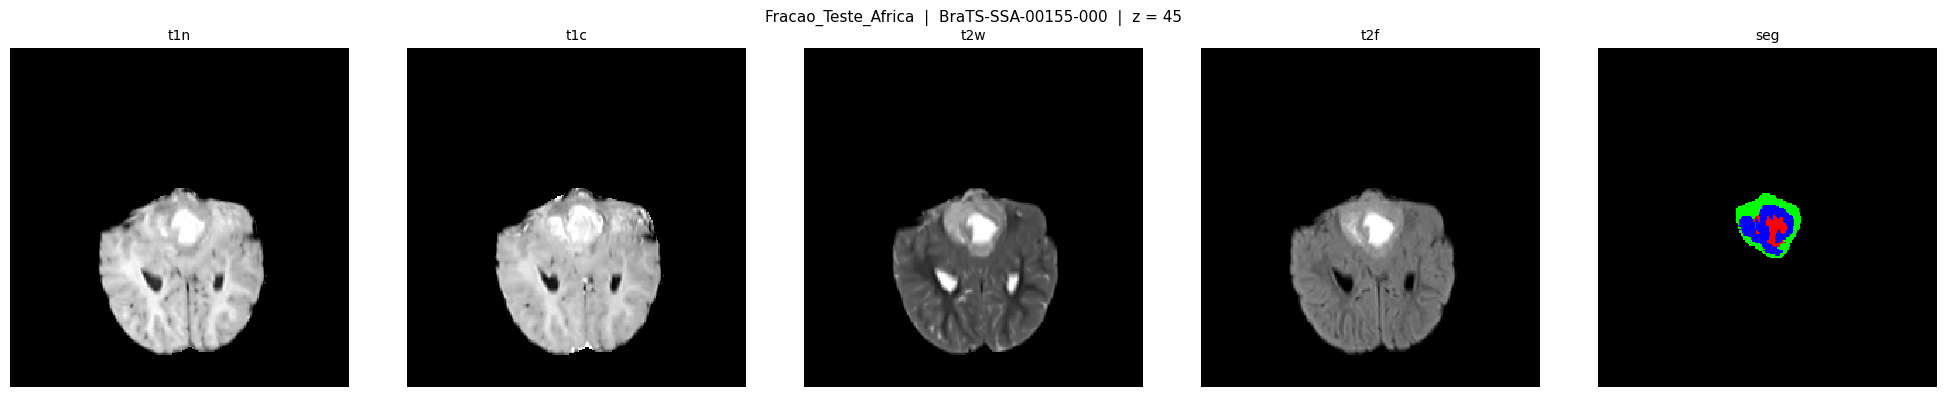

In [16]:
plot_dataset_example('Fracao_Teste_Africa', DATASETS['Fracao_Teste_Africa'])

## Fração de Teste — Pediatric

In [17]:
name = 'Fracao_Teste_Pediatric'
summary_ped, incomplete_ped = analyze_dataset(name, DATASETS[name])
if summary_ped is not None:
    display(summary_ped)

,dataset,total_pacientes,t1n,t1c,t2w,t2f,seg,completos,incompletos,shapes
0,Fracao_Teste_Pediatric,99,99,99,99,99,99,99,0,"(240, 240, 155)"


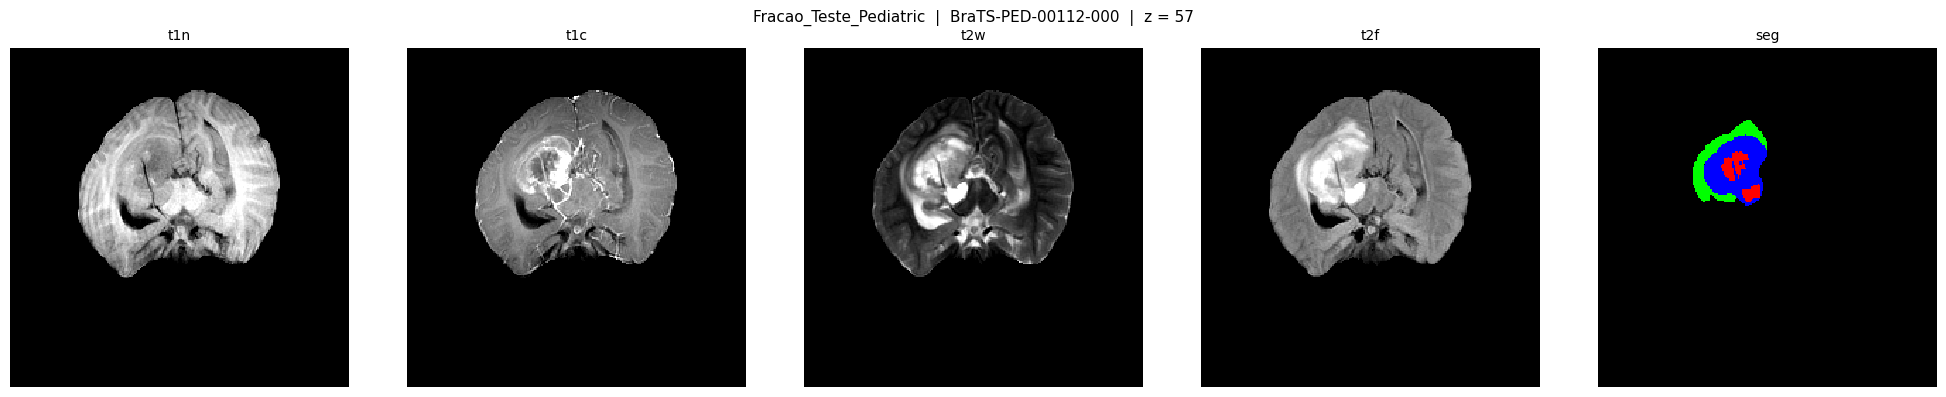

In [18]:
plot_dataset_example('Fracao_Teste_Pediatric', DATASETS['Fracao_Teste_Pediatric'])

## Fração de Teste — Metástases

> Dataset não disponível ainda. A célula abaixo apenas verifica o caminho configurado.

In [19]:
name = 'Fracao_Teste_Metastases'
summary_meta, incomplete_meta = analyze_dataset(name, DATASETS[name])
if summary_meta is not None:
    display(summary_meta)

[AVISO] Caminho não encontrado: CAMINHO_AQUI


In [20]:
plot_dataset_example('Fracao_Teste_Metastases', DATASETS['Fracao_Teste_Metastases'])

---
## Tabela Consolidada

In [21]:
summaries = [
    summary_com_labels, summary_sem_labels, summary_validation,
    summary_glioma, summary_men, summary_africa, summary_ped, summary_meta,
]
all_summaries_df = pd.concat([s for s in summaries if s is not None], ignore_index=True)
display(all_summaries_df)

,dataset,total_pacientes,t1n,t1c,t2w,t2f,seg,completos,incompletos,shapes
0,BraTS_2026_GoAT_Training_Com_Labels,1351,1351,1351,1351,1351,1351,1351,0,"(240, 240, 155)"
1,BraTS_2026_GoAT_Training_Sem_Labels,1138,1138,1138,1138,1138,0,1138,0,"(240, 240, 155)"
2,BraTS_2026_GoAT_Validation,451,451,451,451,451,0,451,0,"(240, 240, 155)"
3,Fracao_Teste_Adult_Glioma,1251,1251,1251,1251,1251,1251,1251,0,"(240, 240, 155)"
4,Fracao_Teste_Meningioma,1000,1000,1000,1000,1000,1000,1000,0,"(240, 240, 155)"
5,Fracao_Teste_Africa,146,146,146,146,146,146,146,0,"(240, 240, 155)"
6,Fracao_Teste_Pediatric,99,99,99,99,99,99,99,0,"(240, 240, 155)"


In [22]:
# ── A) Porcentagem de casos que possuem cada classe/região ───────────────────
# BraTS labels: 1 = NCR/NET (Necrose), 2 = ED (Edema), 3 = ET (Enhancing Tumor)
# Apenas datasets com arquivos de segmentação disponíveis.

LABELED_DATASETS = {
    'BraTS_2026_GoAT_Training_Com_Labels': DATASETS['BraTS_2026_GoAT_Training_Com_Labels'],
    'Fracao_Teste_Adult_Glioma':           DATASETS['Fracao_Teste_Adult_Glioma'],
    'Fracao_Teste_Meningioma':             DATASETS['Fracao_Teste_Meningioma'],
    'Fracao_Teste_Africa':                 DATASETS['Fracao_Teste_Africa'],
    'Fracao_Teste_Pediatric':              DATASETS['Fracao_Teste_Pediatric'],
}

presence_rows = []

for ds_name, ds_path in LABELED_DATASETS.items():
    pdirs = find_patient_dirs(Path(ds_path))
    total = has_ncr = has_ed = has_et = 0

    for pdir in tqdm(pdirs, desc=ds_name, leave=False):
        seg_f = _mod_file(pdir, 'seg')
        if seg_f is None:
            continue
        seg = np.asanyarray(nib.load(str(seg_f)).dataobj)
        total   += 1
        has_ncr += int((seg == 1).any())
        has_ed  += int((seg == 2).any())
        has_et  += int((seg == 3).any())

    if total > 0:
        presence_rows.append({
            'dataset':        ds_name,
            'total_casos':    total,
            'pct_com_ncr':    round(100 * has_ncr / total, 1),
            'pct_com_edema':  round(100 * has_ed  / total, 1),
            'pct_com_et':     round(100 * has_et  / total, 1),
        })

df_presenca = pd.DataFrame(presence_rows, columns=[
    'dataset', 'total_casos',
    'pct_com_ncr', 'pct_com_edema', 'pct_com_et',
])
print("Porcentagem de casos que possuem cada classe (1=NCR, 2=Edema, 3=ET):")
display(df_presenca)

Porcentagem de casos que possuem cada classe (1=NCR, 2=Edema, 3=ET):


,dataset,total_casos,pct_com_ncr,pct_com_edema,pct_com_et
0,BraTS_2026_GoAT_Training_Com_Labels,1351,92.9,98.1,97.6
1,Fracao_Teste_Adult_Glioma,1251,96.6,99.9,97.4
2,Fracao_Teste_Meningioma,1000,33.9,53.6,99.9
3,Fracao_Teste_Africa,146,91.8,99.3,98.6
4,Fracao_Teste_Pediatric,99,100.0,57.6,88.9


In [23]:
# ── B) Proporção de voxels tumorais por classe ───────────────────────────────
# Para cada dataset com seg: soma os voxels de cada classe em todos os casos
# e calcula a proporção em relação ao total de voxels tumorais (classes 1+2+3).
# Depende de LABELED_DATASETS definido na célula anterior.

voxel_rows = []

for ds_name, ds_path in LABELED_DATASETS.items():
    pdirs = find_patient_dirs(Path(ds_path))
    vox_ncr = vox_ed = vox_et = 0

    for pdir in tqdm(pdirs, desc=ds_name, leave=False):
        seg_f = _mod_file(pdir, 'seg')
        if seg_f is None:
            continue
        seg = np.asanyarray(nib.load(str(seg_f)).dataobj)
        vox_ncr += int((seg == 1).sum())
        vox_ed  += int((seg == 2).sum())
        vox_et  += int((seg == 3).sum())

    total_tumor = vox_ncr + vox_ed + vox_et
    if total_tumor > 0:
        voxel_rows.append({
            'dataset':            ds_name,
            'total_voxels_tumor': total_tumor,
            'pct_voxels_ncr':     round(100 * vox_ncr / total_tumor, 1),
            'pct_voxels_edema':   round(100 * vox_ed  / total_tumor, 1),
            'pct_voxels_et':      round(100 * vox_et  / total_tumor, 1),
        })

df_voxels = pd.DataFrame(voxel_rows, columns=[
    'dataset', 'total_voxels_tumor',
    'pct_voxels_ncr', 'pct_voxels_edema', 'pct_voxels_et',
])
print("Proporção de voxels tumorais por classe (1=NCR, 2=Edema, 3=ET):")
display(df_voxels)

Proporção de voxels tumorais por classe (1=NCR, 2=Edema, 3=ET):


,dataset,total_voxels_tumor,pct_voxels_ncr,pct_voxels_edema,pct_voxels_et
0,BraTS_2026_GoAT_Training_Com_Labels,125045926,14.5,63.1,22.5
1,Fracao_Teste_Adult_Glioma,120055496,14.9,62.7,22.3
2,Fracao_Teste_Meningioma,43048622,2.5,47.8,49.7
3,Fracao_Teste_Africa,21708477,11.7,59.6,28.7
4,Fracao_Teste_Pediatric,5632397,66.9,15.0,18.1


## Pacientes com Arquivos Faltando

In [24]:
all_incomplete = (incomplete_com_labels + incomplete_sem_labels + incomplete_validation
                  + incomplete_glioma + incomplete_men + incomplete_africa
                  + incomplete_ped + incomplete_meta)
missing_files_df = (pd.DataFrame(all_incomplete) if all_incomplete
                    else pd.DataFrame(columns=['dataset', 'paciente', 'modalidades_faltando']))
print(f'Total de pacientes com arquivos faltando: {len(missing_files_df)}')
display(missing_files_df)

Total de pacientes com arquivos faltando: 0


,dataset,paciente,modalidades_faltando


---
## Verificação robusta de arquivos corrompidos e duplicatas

Análise completa em **todos os arquivos NIfTI** de **todos os datasets configurados**.
Detecta corrupção, gera hashes baseados no conteúdo da imagem (não nos bytes do `.gz`)
e identifica duplicatas arquivo por arquivo.

### 1. Configuração e imports adicionais

In [25]:
import hashlib

OUTPUT_DIR = Path('D:/brats_goat_experiments/notebooks')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_CORROMPIDOS = OUTPUT_DIR / 'arquivos_corrompidos_brats2026.csv'
CSV_HASHES      = OUTPUT_DIR / 'hashes_arquivos_brats2026.csv'
CSV_DUPLICATAS  = OUTPUT_DIR / 'duplicatas_arquivo_por_arquivo_brats2026.csv'
CSV_ERROS_HASH  = OUTPUT_DIR / 'erros_hash_brats2026.csv'

### 2. Listagem de arquivos NIfTI

Coleta todos os `.nii` e `.nii.gz` em todos os datasets, sem assumir estrutura de pasta de paciente.

In [26]:
def list_nifti_files(root_path):
    root = Path(root_path)
    if not root.exists():
        return []
    return sorted(list(root.rglob('*.nii.gz')) + list(root.rglob('*.nii')))


def collect_all_files(datasets):
    rows = []
    for ds_name, ds_path in datasets.items():
        for f in list_nifti_files(ds_path):
            rows.append({
                'dataset':        ds_name,
                'file_path':      str(f),
                'file_name':      f.name,
                'subject_folder': f.parent.name,
            })
    return pd.DataFrame(rows, columns=['dataset', 'file_path', 'file_name', 'subject_folder'])


df_arquivos = collect_all_files(DATASETS)
print(f'Arquivos NIfTI encontrados: {len(df_arquivos)}')
display(df_arquivos.groupby('dataset').size().rename('quantidade').to_frame())

Arquivos NIfTI encontrados: 25591


,quantidade
dataset,
BraTS_2026_GoAT_Training_Com_Labels,6755
BraTS_2026_GoAT_Training_Sem_Labels,4552
BraTS_2026_GoAT_Validation,1804
Fracao_Teste_Adult_Glioma,6255
Fracao_Teste_Africa,730
Fracao_Teste_Meningioma,5000
Fracao_Teste_Pediatric,495


### 3. Função de teste de abertura (detecção de corrupção)

Tenta abrir o arquivo, ler o header, o shape e uma fatia dos dados via `dataobj`. Captura qualquer exceção.

In [27]:
def test_file_integrity(filepath):
    try:
        img = nib.load(str(filepath))
        _ = img.header
        shape = img.shape
        # Lê uma fatia para validar acesso real aos dados (mais rápido que get_fdata completo)
        if len(shape) >= 3:
            _ = np.asarray(img.dataobj[..., shape[-1] // 2])
        else:
            _ = np.asarray(img.dataobj)
        return None
    except Exception as e:
        return type(e).__name__, str(e)

### 4. Execução da varredura de arquivos corrompidos

In [28]:
corrompidos = []
for row in tqdm(df_arquivos.itertuples(index=False), total=len(df_arquivos), desc='Verificando integridade'):
    err = test_file_integrity(row.file_path)
    if err is not None:
        err_type, err_msg = err
        corrompidos.append({
            'dataset':       row.dataset,
            'file_path':     row.file_path,
            'file_name':     row.file_name,
            'error_type':    err_type,
            'error_message': err_msg,
        })

df_corrompidos = pd.DataFrame(corrompidos, columns=['dataset', 'file_path', 'file_name', 'error_type', 'error_message'])
df_corrompidos.to_csv(CSV_CORROMPIDOS, index=False, encoding='utf-8')

print(f'Arquivos corrompidos: {len(df_corrompidos)}')
print(f'CSV salvo: {CSV_CORROMPIDOS}')
display(df_corrompidos.head(20))

Verificando integridade: 100%|██████████| 25591/25591 [12:33<00:00, 33.98it/s]

Arquivos corrompidos: 0
CSV salvo: D:\brats_goat_experiments\notebooks\arquivos_corrompidos_brats2026.csv


,dataset,file_path,file_name,error_type,error_message


### 5. Funções de hash robusto

- `file_hash_raw`: MD5 dos bytes do arquivo original (depende da compressão).
- `image_hash_content`: MD5 baseado em `shape + affine + array de voxels` (independente da compressão e dos metadados não-essenciais). Este é o hash usado para duplicatas.

In [29]:
def file_hash_raw(filepath, chunk=1 << 20):
    h = hashlib.md5()
    with open(filepath, 'rb') as f:
        for block in iter(lambda: f.read(chunk), b''):
            h.update(block)
    return h.hexdigest()


def image_hash_content(filepath):
    img = nib.load(str(filepath))
    shape = tuple(img.shape)
    h = hashlib.md5()
    h.update(repr(shape).encode())
    h.update(np.ascontiguousarray(img.affine, dtype=np.float64).tobytes())
    data = np.ascontiguousarray(img.get_fdata(dtype=np.float32))
    h.update(data.tobytes())
    return h.hexdigest(), shape, str(data.dtype)

### 6. Geração de hashes dos arquivos válidos

In [30]:
arquivos_validos = df_arquivos[~df_arquivos['file_path'].isin(df_corrompidos['file_path'])]

hashes_rows = []
erros_hash  = []

for row in tqdm(arquivos_validos.itertuples(index=False), total=len(arquivos_validos), desc='Calculando hashes'):
    try:
        img_hash, shape, dtype = image_hash_content(row.file_path)
        raw_hash = file_hash_raw(row.file_path)
        hashes_rows.append({
            'dataset':            row.dataset,
            'subject_folder':     row.subject_folder,
            'file_path':          row.file_path,
            'file_name':          row.file_name,
            'shape':              str(shape),
            'dtype':              dtype,
            'image_hash_content': img_hash,
            'file_hash_raw':      raw_hash,
        })
    except Exception as e:
        erros_hash.append({
            'dataset':       row.dataset,
            'file_path':     row.file_path,
            'file_name':     row.file_name,
            'error_type':    type(e).__name__,
            'error_message': str(e),
        })

df_hashes     = pd.DataFrame(hashes_rows, columns=['dataset', 'subject_folder', 'file_path', 'file_name',
                                                    'shape', 'dtype', 'image_hash_content', 'file_hash_raw'])
df_erros_hash = pd.DataFrame(erros_hash,  columns=['dataset', 'file_path', 'file_name', 'error_type', 'error_message'])

df_hashes.to_csv(CSV_HASHES,         index=False, encoding='utf-8')
df_erros_hash.to_csv(CSV_ERROS_HASH, index=False, encoding='utf-8')

print(f'Hashes gerados: {len(df_hashes)}')
print(f'Erros durante hash: {len(df_erros_hash)}')
print(f'CSV salvo: {CSV_HASHES}')
display(df_hashes.head())

Calculando hashes: 100%|██████████| 25591/25591 [57:07<00:00,  7.47it/s]  


Hashes gerados: 25590
Erros durante hash: 1
CSV salvo: D:\brats_goat_experiments\notebooks\hashes_arquivos_brats2026.csv


,dataset,subject_folder,file_path,file_name,shape,dtype,image_hash_content,file_hash_raw
0,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-00000,D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-00000-seg.nii.gz,"(240, 240, 155)",float32,a78ad13012932c7a2a7e3b86a3c5655b,48d83d6142b5e02101894c7bf851ba02
1,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-00000,D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-00000-t1c.nii.gz,"(240, 240, 155)",float32,13603c2d4a52b84b90e03ffdfec9dfdc,7484caddcf00f3e10000ac592f3742f8
2,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-00000,D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-00000-t1n.nii.gz,"(240, 240, 155)",float32,07fbaeb0237fd4d811078b8003c58536,6762540949a672b0a23f3f812ab0a018
3,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-00000,D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-00000-t2f.nii.gz,"(240, 240, 155)",float32,f75664e4d2eeb36ce170ba4daa63861d,77ba70d1f880f389ada3cbf4073f95b5
4,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-00000,D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-00000-t2w.nii.gz,"(240, 240, 155)",float32,33db8cac6a95e2f07d6f9efdc98aa22b,9dad6129440869420ad5a7dc67a746f6


### 7. Detecção de duplicatas arquivo por arquivo

Agrupa por `image_hash_content`. Cada grupo com mais de um arquivo representa conteúdo idêntico (independente do nome/dataset).

In [31]:
hash_counts       = df_hashes['image_hash_content'].value_counts()
hashes_duplicados = hash_counts[hash_counts > 1].index

df_dup = df_hashes[df_hashes['image_hash_content'].isin(hashes_duplicados)].copy()
df_dup['duplicate_group_id'] = df_dup.groupby('image_hash_content').ngroup()

group_info = df_dup.groupby('duplicate_group_id').agg(
    quantidade_arquivos=('file_path', 'count'),
    datasets_envolvidos=('dataset', lambda s: ', '.join(sorted(set(s)))),
).reset_index()

df_duplicatas = (df_dup.merge(group_info, on='duplicate_group_id')
                       [['duplicate_group_id', 'image_hash_content',
                         'quantidade_arquivos', 'datasets_envolvidos',
                         'file_path', 'file_name', 'subject_folder']]
                       .sort_values(['duplicate_group_id', 'file_path'])
                       .reset_index(drop=True))

df_duplicatas.to_csv(CSV_DUPLICATAS, index=False, encoding='utf-8')

print(f'Hashes duplicados (grupos): {len(hashes_duplicados)}')
print(f'Arquivos envolvidos em duplicatas: {len(df_duplicatas)}')
print(f'CSV salvo: {CSV_DUPLICATAS}')
display(df_duplicatas.head(20))

Hashes duplicados (grupos): 10189
Arquivos envolvidos em duplicatas: 20382
CSV salvo: D:\brats_goat_experiments\notebooks\duplicatas_arquivo_por_arquivo_brats2026.csv


,duplicate_group_id,image_hash_content,quantidade_arquivos,datasets_envolvidos,file_path,file_name,subject_folder
0,0,0002572cdc40096ef536e8267795636b,2,"BraTS_2026_GoAT_Training_Com_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-00532-t1c.nii.gz,BraTS-GoAT-00532
1,0,0002572cdc40096ef536e8267795636b,2,"BraTS_2026_GoAT_Training_Com_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_outside_tes...,BraTS-GLI-00400-000-t1c.nii.gz,BraTS-GLI-00400-000
2,1,0004f2e94cb8bda0a3df843b85b7484f,2,"BraTS_2026_GoAT_Training_Com_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-02362-t1n.nii.gz,BraTS-GoAT-02362
3,1,0004f2e94cb8bda0a3df843b85b7484f,2,"BraTS_2026_GoAT_Training_Com_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_outside_tes...,BraTS-GLI-01496-000-t1n.nii.gz,BraTS-GLI-01496-000
4,2,0005237fca5bf0937ac9899b3a9d37cd,2,"BraTS_2026_GoAT_Training_Com_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-01535-t1c.nii.gz,BraTS-GoAT-01535
5,2,0005237fca5bf0937ac9899b3a9d37cd,2,"BraTS_2026_GoAT_Training_Com_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_outside_tes...,BraTS-GLI-01365-000-t1c.nii.gz,BraTS-GLI-01365-000
6,3,00077724d406a43c97655b3e5a68223c,2,"BraTS_2026_GoAT_Training_Sem_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-01725-t2w.nii.gz,BraTS-GoAT-01725
7,3,00077724d406a43c97655b3e5a68223c,2,"BraTS_2026_GoAT_Training_Sem_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_outside_tes...,BraTS-MEN-01435-001-t2w.nii.gz,BraTS-MEN-01435-001
8,4,000c4eca15bf44ccfe752d0f6304ccb2,2,"BraTS_2026_GoAT_Training_Com_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_oficial_tra...,BraTS-GoAT-00337-t1c.nii.gz,BraTS-GoAT-00337
9,4,000c4eca15bf44ccfe752d0f6304ccb2,2,"BraTS_2026_GoAT_Training_Com_Labels, Fracao_Te...",D:\brats_goat_experiments\data\raw_outside_tes...,BraTS-GLI-01260-000-t1c.nii.gz,BraTS-GLI-01260-000


### 8. Resumo final

Quadro consolidado: totais, classificação intra/cross-dataset e tabela por par de datasets.

In [32]:
total_arquivos    = len(df_arquivos)
total_corrompidos = len(df_corrompidos)
total_validos     = len(df_hashes)
total_hash_dup    = len(hashes_duplicados)
total_arq_dup     = len(df_duplicatas)

# Classificação dos grupos: intra-dataset (1 dataset) ou cross-dataset (>=2 datasets)
group_ndatasets = df_dup.groupby('duplicate_group_id')['dataset'].nunique()
intra = int((group_ndatasets == 1).sum())
cross = int((group_ndatasets >= 2).sum())

resumo = pd.DataFrame([
    {'metrica': 'Total de arquivos analisados',          'valor': total_arquivos},
    {'metrica': 'Arquivos corrompidos',                  'valor': total_corrompidos},
    {'metrica': 'Arquivos validos (com hash)',           'valor': total_validos},
    {'metrica': 'Hashes duplicados (grupos)',            'valor': total_hash_dup},
    {'metrica': 'Arquivos envolvidos em duplicatas',     'valor': total_arq_dup},
    {'metrica': 'Grupos intra-dataset',                  'valor': intra},
    {'metrica': 'Grupos cross-dataset',                  'valor': cross},
])
display(resumo)

# Tabela por par de datasets (apenas cross-dataset)
pares = []
for gid, g in df_dup.groupby('duplicate_group_id'):
    ds_list = sorted(g['dataset'].unique())
    if len(ds_list) < 2:
        continue
    for i in range(len(ds_list)):
        for j in range(i + 1, len(ds_list)):
            ds_a, ds_b = ds_list[i], ds_list[j]
            n_files = int((g['dataset'] == ds_a).sum() + (g['dataset'] == ds_b).sum())
            pares.append({'dataset_a': ds_a, 'dataset_b': ds_b,
                          'duplicate_group_id': gid, 'n_files': n_files})

if pares:
    df_pares = (pd.DataFrame(pares)
                .groupby(['dataset_a', 'dataset_b'])
                .agg(quantidade_hashes_duplicados=('duplicate_group_id', 'nunique'),
                     quantidade_arquivos_envolvidos=('n_files', 'sum'))
                .reset_index()
                .sort_values('quantidade_hashes_duplicados', ascending=False))
    print('Duplicatas por par de datasets:')
    display(df_pares)
else:
    print('Nenhuma duplicata cross-dataset encontrada.')

,metrica,valor
0,Total de arquivos analisados,25591
1,Arquivos corrompidos,0
2,Arquivos validos (com hash),25590
3,Hashes duplicados (grupos),10189
4,Arquivos envolvidos em duplicatas,20382
5,Grupos intra-dataset,12
6,Grupos cross-dataset,10177


Duplicatas por par de datasets:


,dataset_a,dataset_b,quantidade_hashes_duplicados,quantidade_arquivos_envolvidos
0,BraTS_2026_GoAT_Training_Com_Labels,Fracao_Teste_Adult_Glioma,6255,12510
2,BraTS_2026_GoAT_Training_Sem_Labels,Fracao_Teste_Meningioma,3628,7256
1,BraTS_2026_GoAT_Training_Com_Labels,Fracao_Teste_Meningioma,234,468
3,BraTS_2026_GoAT_Validation,Fracao_Teste_Africa,60,124


---
## Duplicatas paciente-a-paciente

Faz a análise de duplicatas do nível de **arquivo** para o nível de **paciente** (pasta).
A comparação ainda é feita pelo conteúdo dos volumes (`image_hash_content`), agora agrupada
por modalidade dentro de cada paciente. Dois pacientes são considerados o mesmo se ao menos uma
modalidade tiver hash idêntico — em prática, hash MD5 do array de voxels não colide por acaso.

Saídas:
- `df_test_leak`: pacientes do teste externo que também aparecem no treino.
- `df_train_intra`: pacientes repetidos dentro dos próprios dados de treino (Com_Labels e Sem_Labels).

### Construção dos pares paciente-paciente

In [33]:
# Identifica modalidade pelo sufixo do nome (sem assumir formato fixo do dataset)
def _modality_from_filename(filename):
    base = filename.replace('.nii.gz', '').replace('.nii', '')
    for mod in MODALITIES:
        if base.endswith(f'-{mod}') or base.endswith(f'_{mod}'):
            return mod
    return None

df_pat = df_hashes.copy()
df_pat['modality'] = df_pat['file_name'].apply(_modality_from_filename)
df_pat = df_pat[df_pat['modality'].notna()].reset_index(drop=True)

# Índice invertido: (modalidade, hash) -> [(dataset, paciente)]
hash_index = {}
for r in df_pat.itertuples(index=False):
    hash_index.setdefault((r.modality, r.image_hash_content), []).append((r.dataset, r.subject_folder))

# Para cada par de pacientes que aparece junto em algum bucket, registra as modalidades coincidentes
pair_modalities = {}
for (mod, h), patients in hash_index.items():
    uniq = list(set(patients))
    for i in range(len(uniq)):
        for j in range(i + 1, len(uniq)):
            a, b = uniq[i], uniq[j]
            key = tuple(sorted([a, b]))
            pair_modalities.setdefault(key, set()).add(mod)

print(f'Pares paciente-paciente com ao menos 1 modalidade coincidente: {len(pair_modalities)}')

Pares paciente-paciente com ao menos 1 modalidade coincidente: 2228


### Pacientes do teste que aparecem no treino

Cada linha é uma associação entre um paciente do test set externo e um paciente do conjunto
de treino com volumes idênticos.

In [34]:
# Define quem é treino (Com/Sem labels) e quem é "outside test" (qualquer dataset cujo path está em raw_outside_test_set/)
TRAINING_DATASETS = {'BraTS_2026_GoAT_Training_Com_Labels', 'BraTS_2026_GoAT_Training_Sem_Labels'}
SRC_OUTSIDE_RES   = Path('D:/brats_goat_experiments/data/raw_outside_test_set').resolve()
OUTSIDE_DATASETS  = {n for n, p in DATASETS.items()
                     if Path(p).exists() and SRC_OUTSIDE_RES in Path(p).resolve().parents}

leak_rows = []
for (a, b), mods in pair_modalities.items():
    ds_a, pac_a = a
    ds_b, pac_b = b
    if ds_a in TRAINING_DATASETS and ds_b in OUTSIDE_DATASETS:
        train_side, test_side = (ds_a, pac_a), (ds_b, pac_b)
    elif ds_b in TRAINING_DATASETS and ds_a in OUTSIDE_DATASETS:
        train_side, test_side = (ds_b, pac_b), (ds_a, pac_a)
    else:
        continue
    leak_rows.append({
        'dataset_teste':          test_side[0],
        'paciente_teste':         test_side[1],
        'dataset_treino':         train_side[0],
        'paciente_treino':        train_side[1],
        'modalidades_iguais':     ','.join(sorted(mods)),
        'qtd_modalidades_iguais': len(mods),
    })

df_test_leak = pd.DataFrame(leak_rows, columns=[
    'dataset_teste', 'paciente_teste',
    'dataset_treino', 'paciente_treino',
    'modalidades_iguais', 'qtd_modalidades_iguais',
]).sort_values(['dataset_teste', 'paciente_teste']).reset_index(drop=True)

n_pacientes_teste = df_test_leak.groupby(['dataset_teste', 'paciente_teste']).ngroups
print(f'Pacientes do teste que aparecem no treino: {n_pacientes_teste}')
print(f'Total de pares teste<->treino: {len(df_test_leak)}')
display(df_test_leak)

Pacientes do teste que aparecem no treino: 2208
Total de pares teste<->treino: 2208


,dataset_teste,paciente_teste,dataset_treino,paciente_treino,modalidades_iguais,qtd_modalidades_iguais
0,Fracao_Teste_Adult_Glioma,BraTS-GLI-00000-000,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-01560,"seg,t1c,t1n,t2f,t2w",5
1,Fracao_Teste_Adult_Glioma,BraTS-GLI-00002-000,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-00077,"seg,t1c,t1n,t2f,t2w",5
2,Fracao_Teste_Adult_Glioma,BraTS-GLI-00003-000,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-00769,"seg,t1c,t1n,t2f,t2w",5
3,Fracao_Teste_Adult_Glioma,BraTS-GLI-00005-000,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-01162,"seg,t1c,t1n,t2f,t2w",5
4,Fracao_Teste_Adult_Glioma,BraTS-GLI-00006-000,BraTS_2026_GoAT_Training_Com_Labels,BraTS-GoAT-00861,"seg,t1c,t1n,t2f,t2w",5
...,...,...,...,...,...,...
2203,Fracao_Teste_Meningioma,BraTS-MEN-01432-000,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-00824,"t1c,t1n,t2f,t2w",4
2204,Fracao_Teste_Meningioma,BraTS-MEN-01433-000,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-00331,"t1c,t1n,t2f,t2w",4
2205,Fracao_Teste_Meningioma,BraTS-MEN-01434-000,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-01801,"t1c,t1n,t2f,t2w",4
2206,Fracao_Teste_Meningioma,BraTS-MEN-01435-000,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-02271,"t1c,t1n,t2f,t2w",4


### Pacientes repetidos dentro do treino

Cada linha é um par de pastas de paciente — ambas em datasets de treino — com volumes
coincidentes. Inclui repetições intra-Com_Labels, intra-Sem_Labels e cruzadas Com↔Sem.

In [35]:
intra_rows = []
for (a, b), mods in pair_modalities.items():
    ds_a, pac_a = a
    ds_b, pac_b = b
    if ds_a in TRAINING_DATASETS and ds_b in TRAINING_DATASETS:
        intra_rows.append({
            'dataset_a':              ds_a,
            'paciente_a':             pac_a,
            'dataset_b':              ds_b,
            'paciente_b':             pac_b,
            'modalidades_iguais':     ','.join(sorted(mods)),
            'qtd_modalidades_iguais': len(mods),
        })

df_train_intra = pd.DataFrame(intra_rows, columns=[
    'dataset_a', 'paciente_a',
    'dataset_b', 'paciente_b',
    'modalidades_iguais', 'qtd_modalidades_iguais',
]).sort_values(['dataset_a', 'paciente_a']).reset_index(drop=True)

# Pacientes únicos envolvidos em qualquer par intra-treino
pacientes_intra_treino = pd.concat([
    df_train_intra[['dataset_a', 'paciente_a']].rename(columns={'dataset_a': 'dataset', 'paciente_a': 'paciente'}),
    df_train_intra[['dataset_b', 'paciente_b']].rename(columns={'dataset_b': 'dataset', 'paciente_b': 'paciente'}),
]).drop_duplicates().sort_values(['dataset', 'paciente']).reset_index(drop=True)

print(f'Pares paciente<->paciente intra-treino: {len(df_train_intra)}')
print(f'Pacientes únicos envolvidos em duplicatas intra-treino: {len(pacientes_intra_treino)}')
display(df_train_intra)
display(pacientes_intra_treino)

Pares paciente<->paciente intra-treino: 2
Pacientes únicos envolvidos em duplicatas intra-treino: 4


,dataset_a,paciente_a,dataset_b,paciente_b,modalidades_iguais,qtd_modalidades_iguais
0,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-00242,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-02210,"t1c,t1n,t2f",3
1,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-01639,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-01774,"t1c,t1n,t2f,t2w",4


,dataset,paciente
0,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-00242
1,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-01639
2,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-01774
3,BraTS_2026_GoAT_Training_Sem_Labels,BraTS-GoAT-02210
